# 2. Simple Linear Regression (using `Python` libraries)

`Python` provides a collection of libraries that streamline the implementation of linear regression, making the code more concise and straightforward.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Avoid code suggestions
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data generation
N = 1000
theta_1 = np.random.normal(loc=2, scale=1, size=N)
theta_0 = np.random.randn(1)
x = np.random.randn(N)
y = theta_1 * x + theta_0 + np.random.randn(N)

# Create a design matrix with a column of ones for the constant term
X = sm.add_constant(x)

# Create the linear model using OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

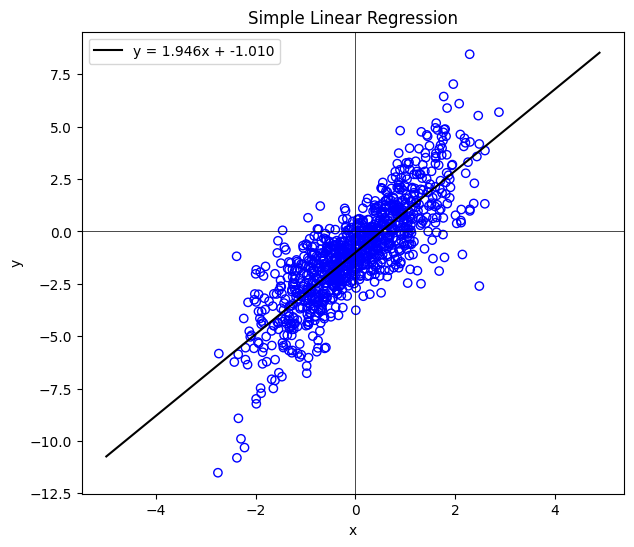

In [3]:
# Estimated coefficients
theta_0 = model.params[0]
theta_1 = model.params[1]

# Plot
x_seq = np.arange(-5, 5, 0.1)
y_pre = x_seq * theta_1 + theta_0

plt.figure(figsize=(7, 6))
plt.title("Simple Linear Regression")

# Data
plt.scatter(x, y, marker='o', facecolors='none', edgecolors='blue')

# Fitted line
plt.plot(x_seq, y_pre, c="black", label=f"y = {theta_1:.3f}x + {theta_0:.3f}")

# Axes
plt.axhline(y=0, color="black", linewidth=0.5)
plt.axvline(x=0, color="black", linewidth=0.5)

# Horizontal axis label
plt.xlabel("x")
# Vertical axis label
plt.ylabel("y")

# Show legend
plt.legend()

plt.show()

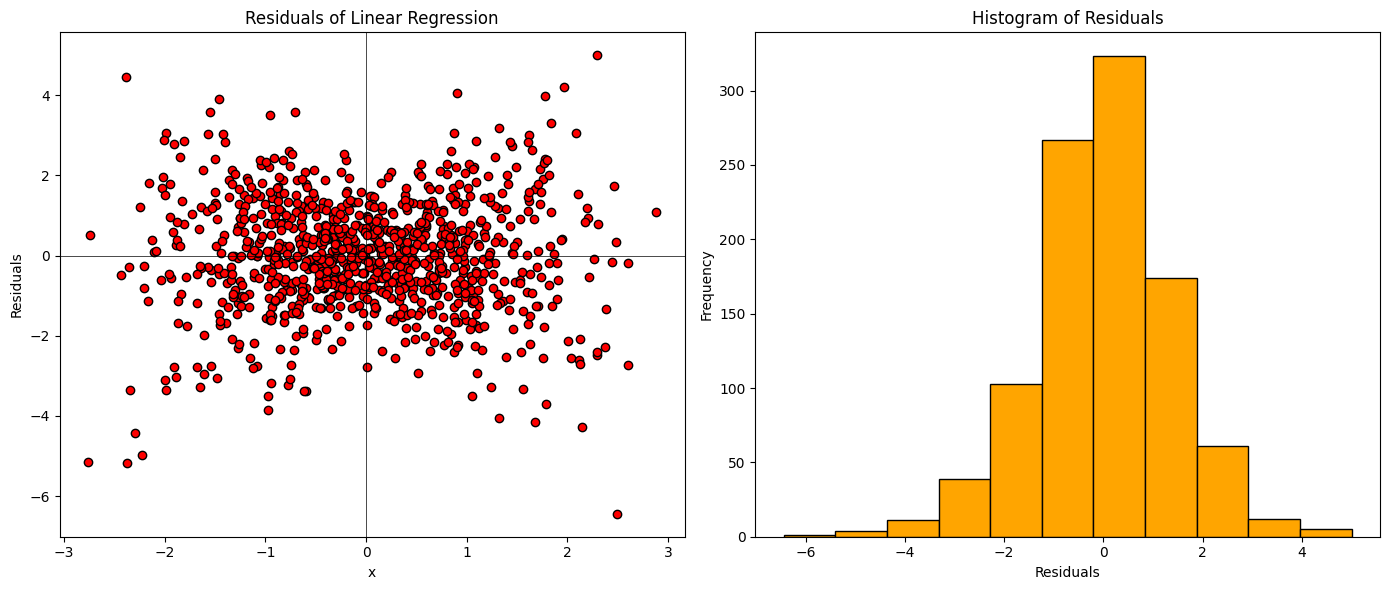

In [4]:
# Calculate residuals
residuals = y - (theta_1 * x + theta_0)

# Plot residuals
plt.figure(figsize=(14, 6))

# Scatter plot of residuals
plt.subplot(1, 2, 1)
plt.title("Residuals of Linear Regression")
plt.scatter(x, residuals, color="red", edgecolors="black")
plt.axhline(y=0, color="black", linewidth=0.5)
plt.axvline(x=0, color="black", linewidth=0.5)
plt.xlabel("x")
plt.ylabel("Residuals")

# Plot histogram of residuals with adjusted binning
plt.subplot(1, 2, 2)
plt.hist(residuals, bins='sturges', color="orange", edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [5]:
# Estimated values
y_hat = model.predict(X)

# Calculate the mean value of y
mean_y = np.mean(y_hat)

# Calculate the Variance of RSS (RSE^2)
VarRss = np.sum(model.resid ** 2) / (N - 2)

# Calculate the RSE (estimator of sigma)
RSE = np.sqrt(VarRss)

# Calculate the standard errors of the coefficients
SE_theta_0 = RSE * np.sqrt(1/N + np.mean(x)**2 / np.sum((x - np.mean(x))**2))
SE_theta_1 = RSE / np.sqrt(np.sum((x - np.mean(x))**2))

# Calculate the 95% confidence intervals
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df=N - 2)

CI_theta_0 = (theta_0 - t_critical * SE_theta_0, theta_0 + t_critical * SE_theta_0)
CI_theta_1 = (theta_1 - t_critical * SE_theta_1, theta_1 + t_critical * SE_theta_1)
CI_mean_y = (mean_y - t_critical * (RSE / np.sqrt(N)), mean_y + t_critical * (RSE / np.sqrt(N)))

# Print results
print("Mean value of y:", mean_y)
print("Standard error of y:", RSE / np.sqrt(N))
print("Confidence interval for the mean value of y:", CI_mean_y)
print('-----------------------------------------------')
print("SE(theta_0):", SE_theta_0)
print("Confidence interval for theta_0:", CI_theta_0)
print('-----------------------------------')
print("SE(theta_1):", SE_theta_1)
print("Confidence interval for theta_1:", CI_theta_1)
print('-----------------------------------')

Mean value of y: -1.0108895477942
Standard error of y: 0.04387031270095204
Confidence interval for the mean value of y: (-1.0969781859544994, -0.9248009096339004)
-----------------------------------------------
SE(theta_0): 0.043870320974911156
Confidence interval for theta_0: (-1.095753175056148, -0.9235758662628436)
-----------------------------------
SE(theta_1): 0.042808867343920746
Confidence interval for theta_1: (1.8623507263885524, 2.030362161180221)
-----------------------------------


In [6]:
# Calculate the standard errors of the coefficients
SE_theta_0 = model.bse[0]
SE_theta_1 = model.bse[1]

# Calculate the t-statistic and p-value for theta_0
t_stat_theta_0 = theta_0 / SE_theta_0
p_value_theta_0 = 2 * (1 - stats.t.cdf(np.abs(t_stat_theta_0), df=N - 2))

# Calculate the t-statistic and p-value for theta_1
t_stat_theta_1 = theta_1 / SE_theta_1
p_value_theta_1 = 2 * (1 - stats.t.cdf(np.abs(t_stat_theta_1), df=N - 2))

# Calculate the coefficient of determination (R squared)
R_squared = model.rsquared

# Calculate the F-statistic and p-value
F_stat = (R_squared / 1) / ((1 - R_squared) / (N - 2))
p_value_F = 1 - stats.f.cdf(F_stat, dfn=1, dfd=N - 2)

# Create a pandas DataFrame
data = {
    "theta_0": [theta_0],
    "SE(theta_0)": [SE_theta_0],
    "theta_1": [theta_1],
    "SE(theta_1)": [SE_theta_1],
    "t-statistic": [t_stat_theta_1],
    "p-value t": [p_value_theta_1],
    "F-statistic": [F_stat],
    "p-value F": [p_value_F],
    "R^2": [R_squared]
}

statistics_df = pd.DataFrame(data)

statistics_df

,theta_0,SE(theta_0),theta_1,SE(theta_1),t-statistic,p-value t,F-statistic,p-value F,R^2
0,-1.009665,0.04387,1.946356,0.042809,45.466198,0.0,2067.175171,1.110223e-16,0.674407


In [7]:
# Imprimir el resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     2067.
Date:                Mon, 11 Mar 2024   Prob (F-statistic):          2.05e-245
Time:                        23:22:59   Log-Likelihood:                -1745.3
No. Observations:                1000   AIC:                             3495.
Df Residuals:                     998   BIC:                             3504.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0097      0.044    -23.015      0.0